In [1]:

import os
import numpy as np
from PIL import Image
import torch
from sklearn.decomposition import PCA, IncrementalPCA
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = "dataset/train"
IMG_SIZE = (150, 150)  # matches assignment
CLASSES = sorted([d.name for d in Path(DATA_DIR).iterdir() if d.is_dir()])

In [125]:
print(CLASSES)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [2]:
def load_images(max_per_class=None):
    X, y, paths = [], [], []
    for cls_idx, cls in enumerate(CLASSES):
        cls_dir = Path(DATA_DIR) / cls
        files = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        if max_per_class:
            files = files[:max_per_class]
        for p in files:
            img = Image.open(p).convert("RGB").resize(IMG_SIZE)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            X.append(arr.ravel())
            y.append(cls_idx)
            paths.append(str(p))
    return np.stack(X), np.array(y), paths

In [3]:
print('Loading the images ***')
X, y, paths = load_images()
print(X.shape)
print(y.shape)
print(len(paths))

Loading the images ***
(12402, 67500)
(12402,)
12402


In [8]:
#Do basic EDA on the loaded image dataset - show a distribution of number of images per class
class_distribution_map = dict()
for class_,val in zip(paths,y):
    class_label = class_.split('/')[2]
    if class_label not in class_distribution_map.keys():
        class_distribution_map[class_label] = 1
    else:
        class_distribution_map[class_label] += 1
print(class_distribution_map)

{'buildings': 2191, 'forest': 2313, 'glacier': 2388, 'mountain': 2512, 'sea': 2287, 'street': 711}


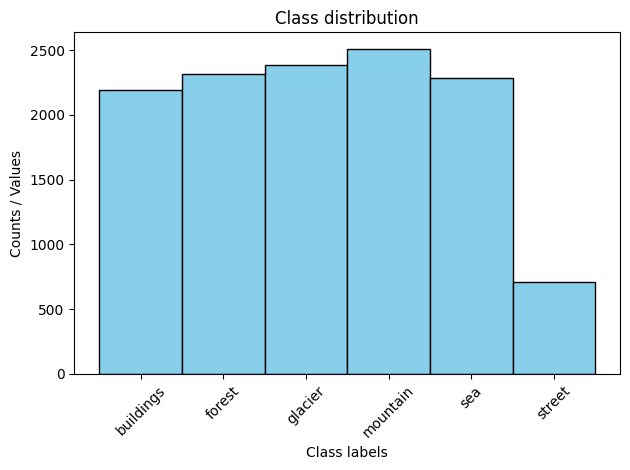

In [9]:
#Class distribution
x_labels = list(class_distribution_map.keys())
y_values = list(class_distribution_map.values())

# 2. Plot using plt.bar
# Setting width=1.0 removes the gaps between bars, giving it a histogram appearance
plt.bar(x_labels, y_values, width=1.0, edgecolor='black', color='skyblue')

# 3. Add labels and title
plt.xlabel('Class labels')
plt.ylabel('Counts / Values')
plt.title('Class distribution')

# Optional: Rotate X-axis labels if they are long or overlapping
plt.xticks(rotation=45)

# 4. Display the plot
plt.tight_layout()  # Adjusts layout so labels aren't cut off
plt.show()

In [10]:
# mean-center(standardization of data)
X_mean = X.mean(axis=0)
Xc = X - X_mean

In [11]:
# PCA for visualization
print('Perform PCA **')
pca = PCA(n_components=2, svd_solver="randomized", random_state=0)
Z = pca.fit_transform(Xc)
print("Explained variance (2 PCs):", pca.explained_variance_ratio_.sum())

Perform PCA **
Explained variance (2 PCs): 0.36897284


In [ ]:
print("Explained variance by component:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

Explained variance by component: [0.23781121 0.13116165]
Total variance captured: 0.36897284


Plotting PCA scatter plot for PCA on 2 axes ***


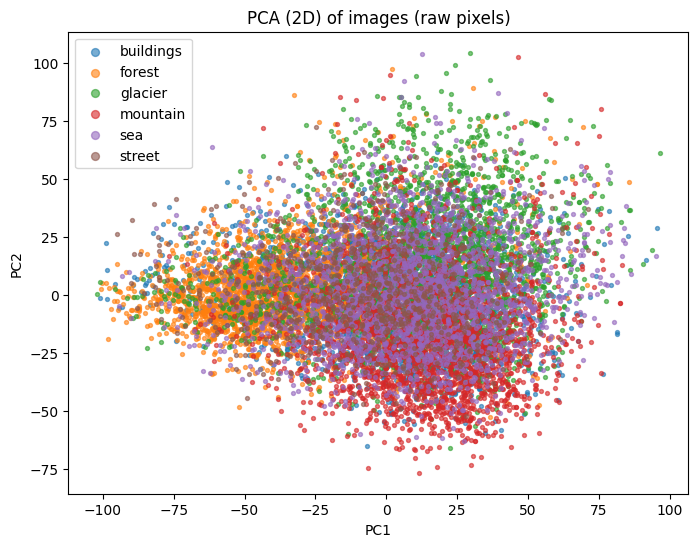

In [8]:
print('Plotting PCA scatter plot for PCA on 2 axes ***')
# scatter
plt.figure(figsize=(8,6))
for cls_idx, cls in enumerate(CLASSES):
    mask = y==cls_idx
    plt.scatter(Z[mask,0], Z[mask,1], s=8, label=cls, alpha=0.6)
plt.legend(markerscale=2)
plt.title("PCA (2D) of images (raw pixels)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [9]:
# PCA on 3 axes
print('Perform PCA **')
pca = PCA(n_components=3, svd_solver="randomized", random_state=0)
Z = pca.fit_transform(Xc)
print("Explained variance (3 PCs):", pca.explained_variance_ratio_.sum())

Perform PCA **
Explained variance (3 PCs): 0.42807546


In [10]:
print("Explained variance by each component:", pca.explained_variance_ratio_)
print("Total variance captured in 3 components:", sum(pca.explained_variance_ratio_))

Explained variance by each component: [0.23781121 0.13116173 0.05910252]
Total variance captured in 3 components: 0.42807546


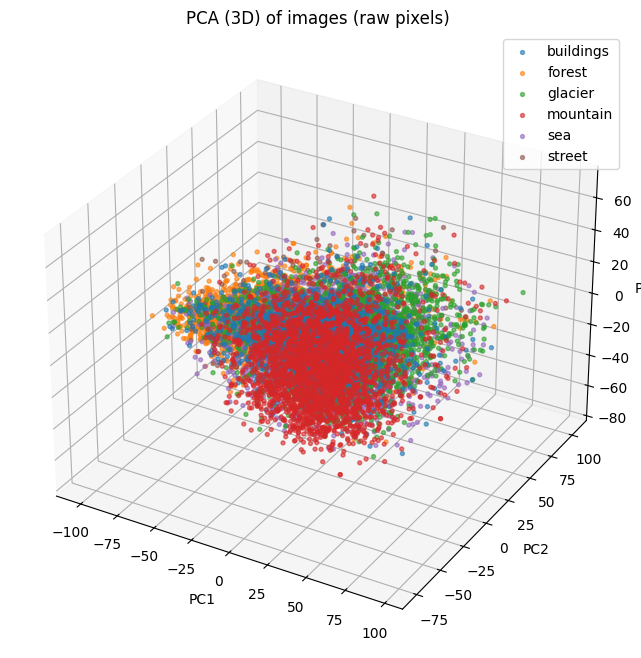

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for cls_idx, cls in enumerate(CLASSES):
    mask = y == cls_idx
    ax.scatter(Z[mask,0], Z[mask,1], Z[mask,2], s=8, label=cls, alpha=0.6)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA (3D) of images (raw pixels)')
ax.legend()
plt.show()

In [15]:
print('Identifying outliers based on PCA projection ***')

# Show top outliers by projection distance from class centroid
outlier_scores = []
for cls_idx in range(len(CLASSES)):
    mask = (y==cls_idx)
    centroid = Z[mask].mean(axis=0)
    dists = np.linalg.norm(Z[mask] - centroid, axis=1)
    # store global mapping
    idxs = np.where(mask)[0]
    for i, dist in zip(idxs, dists):
        outlier_scores.append((dist, i))
outlier_scores.sort(reverse=True)
top = outlier_scores[:50]
print(f'Top outlier scores: {top}')

Identifying outliers based on PCA projection ***


NameError: name 'Z' is not defined

In [ ]:
# Save CSV for review
import csv
print('Writing results to analysis/pca_outliers.csv ***')
with open("analysis/pca_outliers.csv","w",newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["score","index","path","label"])
    for score,i in top:
        writer.writerow([score, i, paths[i], CLASSES[y[i]]])
print("Wrote analysis/pca_outliers.csv (top suspicious samples)")

In [12]:
#GPU check

print(f"Is MPS available? {torch.backends.mps.is_available()}")
print(f"Is MPS built? {torch.backends.mps.is_built()}")

Is MPS available? True
Is MPS built? True


In [13]:
ideal_workers = os.cpu_count()
print(ideal_workers)

8


In [101]:
#Baseline model
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        
        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # We keep the adaptive pool at the end to ensure 
        # the input to the FC layer remains consistent.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.flattened_size = 128 
        
        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # Pass through Conv blocks with MaxPool
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        
        # Collapse remaining spatial dimensions to 1x1
        x = self.global_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [102]:
# Initialize model with number of classes
num_classes = len(CLASSES)
model = CNN(num_classes)

# Print model architecture
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


In [103]:
# Create dataset loader for training
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

class OutdoorSceneDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.images = []
        self.labels = []
        
        for cls_idx, cls in enumerate(CLASSES):
            cls_dir = self.data_dir / cls
            if cls_dir.exists():
                for img_path in cls_dir.glob("*.jpg"):
                    self.images.append(str(img_path))
                    self.labels.append(cls_idx)
                for img_path in cls_dir.glob("*.png"):
                    self.images.append(str(img_path))
                    self.labels.append(cls_idx)
        
        print(f"Loaded {len(self.images)} images from {len(CLASSES)} classes")
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset and dataloader
train_dataset = OutdoorSceneDataset(DATA_DIR, transform=train_transform)

# Use num_workers=0 to avoid multiprocessing issues on macOS with Jupyter notebooks
# num_workers > 0 causes pickling errors with dataset classes defined in notebooks
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# Training setup - Use MPS for M1 Mac GPU acceleration
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple MPS (Metal Performance Shaders) for GPU acceleration")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using CUDA for GPU acceleration")
else:
    device = torch.device('cpu')
    print("Using CPU")

# Move model to device
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(f"Training on {device}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"DataLoader num_workers: 0 (disabled to avoid multiprocessing issues)")

Loaded 12402 images from 6 classes
Using Apple MPS (Metal Performance Shaders) for GPU acceleration
Training on mps
Number of classes: 6
Training samples: 12402
DataLoader num_workers: 0 (disabled to avoid multiprocessing issues)


In [95]:
#Function to reset model weights
def reset_weights(m):
    """
    Resets the weights of a layer to their initial random states.
    """
    # Target Conv2d and Linear layers
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        print('Resetting weights **')
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
            
    # Target BatchNorm layers
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [104]:
#Reset weights before training:
model.apply(reset_weights)

Resetting weights **
Resetting weights **
Resetting weights **
Resetting weights **
Resetting weights **


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

In [105]:
# Training loop(from scratch)
num_epochs = 15
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}] completed. Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

print('Training completed!')

Epoch [1/15], Batch [50/388], Loss: 1.5064
Epoch [1/15], Batch [100/388], Loss: 1.3606
Epoch [1/15], Batch [150/388], Loss: 1.4657
Epoch [1/15], Batch [200/388], Loss: 1.2584
Epoch [1/15], Batch [250/388], Loss: 1.2413
Epoch [1/15], Batch [300/388], Loss: 1.3331
Epoch [1/15], Batch [350/388], Loss: 1.1883
Epoch [1/15] completed. Loss: 1.4488, Accuracy: 45.44%
Epoch [2/15], Batch [50/388], Loss: 1.2012
Epoch [2/15], Batch [100/388], Loss: 1.1309
Epoch [2/15], Batch [150/388], Loss: 1.0060
Epoch [2/15], Batch [200/388], Loss: 0.9707
Epoch [2/15], Batch [250/388], Loss: 1.1649
Epoch [2/15], Batch [300/388], Loss: 1.1424
Epoch [2/15], Batch [350/388], Loss: 0.9436
Epoch [2/15] completed. Loss: 1.1840, Accuracy: 58.56%
Epoch [3/15], Batch [50/388], Loss: 0.9347
Epoch [3/15], Batch [100/388], Loss: 0.9267
Epoch [3/15], Batch [150/388], Loss: 1.1659
Epoch [3/15], Batch [200/388], Loss: 1.2621
Epoch [3/15], Batch [250/388], Loss: 1.1492
Epoch [3/15], Batch [300/388], Loss: 1.2744
Epoch [3/15],

In [106]:
# Define the file path
pth_model_path = "baseline_model.pth"

# Save the state dictionary
torch.save(model.state_dict(), pth_model_path)
print(f"Model weights successfully saved to {pth_model_path}")

Model weights successfully saved to baseline_model.pth


In [107]:
%pip install onnx onnxscript
import torch.onnx

# 1. Put your model into evaluation mode (crucial for dropout/batchnorm layers)
model.eval()

# 2. Create dummy input matching your training data shape: (batch_size, channels, height, width)
# We match your batch_size of 32 and image dimensions of 150x150
dummy_input = torch.rand(32, 3, 150, 150).to(device)

# 3. Define the file path
onnx_model_path = "baseline_model.onnx"

# 4. Export the model
torch.onnx.export(
    model,                  # Your trained model object
    dummy_input,            # Dummy input tensor to trace the architecture
    onnx_model_path,        # Where to save the file
    export_params=True,     # Store the trained parameter weights inside the ONNX file
    opset_version=11,       # Standard, highly compatible ONNX version rule
    do_constant_folding=True, # Optimization trick: folds constant operations
    input_names=['input'],   # Rename input layer for convenience
    output_names=['output'], # Rename output layer for convenience
    # Optional: allows your deployment model to accept flexible batch sizes later
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}} 
)

print(f"Model successfully exported to {onnx_model_path}")

Python(10410) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/ft/c50scrvs41vf32d291y7vww00000gn/T/ipykernel_1060/605539649.py:15: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0607 01:17:58.218000 1060 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/muditjha/Code/ai-masterclass-work/week-4-assignment-mudit-jha06/venv/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/muditjha/Code/ai-masterclass-work/week-4-assignment-mudit-jha06/venv/lib/python3.13/site-packages/onnxscript/ver

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model successfully exported to baseline_model.onnx


In [ ]:
# Evaluate model on validation data (unseen during training)
from sklearn.metrics import classification_report

# Create validation dataset
val_data_dir = "dataset/validation_data"
val_dataset = OutdoorSceneDataset(val_data_dir, transform=train_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Validation samples: {len(val_dataset)}")

# Evaluate on validation set
model.eval()
val_correct = 0
val_total = 0
all_val_labels = []
all_val_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        
        all_val_labels.extend(labels.cpu().numpy())
        all_val_predictions.extend(predicted.cpu().numpy())

val_accuracy = 100 * val_correct / val_total
print(f'\nValidation Accuracy: {val_accuracy:.2f}%')

# Print detailed classification report
print("\nValidation Classification Report:")
print(classification_report(all_val_labels, all_val_predictions, target_names=CLASSES))

Loaded 240 images from 6 classes
Validation samples: 240

Validation Accuracy: 71.67%
Accuracy Gap: 17.07%

Validation Classification Report:
              precision    recall  f1-score   support

   buildings       0.71      0.75      0.73        40
      forest       0.71      0.97      0.82        40
     glacier       0.77      0.75      0.76        40
    mountain       0.64      0.88      0.74        40
         sea       0.72      0.72      0.72        40
      street       1.00      0.23      0.37        40

    accuracy                           0.72       240
   macro avg       0.76      0.72      0.69       240
weighted avg       0.76      0.72      0.69       240



In [109]:
#Testing trained model on validation set
# Evaluate model on validation data (unseen during training)
from sklearn.metrics import classification_report

# Create validation dataset
val_data_dir = "dataset/validation_data"
val_dataset = OutdoorSceneDataset(val_data_dir, transform=train_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Validation samples: {len(val_dataset)}")

# Evaluate on validation set
model.eval()
val_correct = 0
val_total = 0
all_val_labels = []
all_val_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        
        all_val_labels.extend(labels.cpu().numpy())
        all_val_predictions.extend(predicted.cpu().numpy())

val_accuracy = 100 * val_correct / val_total
print(f'\nValidation Accuracy: {val_accuracy:.2f}%')

# Print detailed classification report
print("\nValidation Classification Report:")
print(classification_report(all_val_labels, all_val_predictions, target_names=CLASSES))

Loaded 240 images from 6 classes
Validation samples: 240

Validation Accuracy: 71.67%

Validation Classification Report:
              precision    recall  f1-score   support

   buildings       0.71      0.75      0.73        40
      forest       0.71      0.97      0.82        40
     glacier       0.77      0.75      0.76        40
    mountain       0.64      0.88      0.74        40
         sea       0.72      0.72      0.72        40
      street       1.00      0.23      0.37        40

    accuracy                           0.72       240
   macro avg       0.76      0.72      0.69       240
weighted avg       0.76      0.72      0.69       240



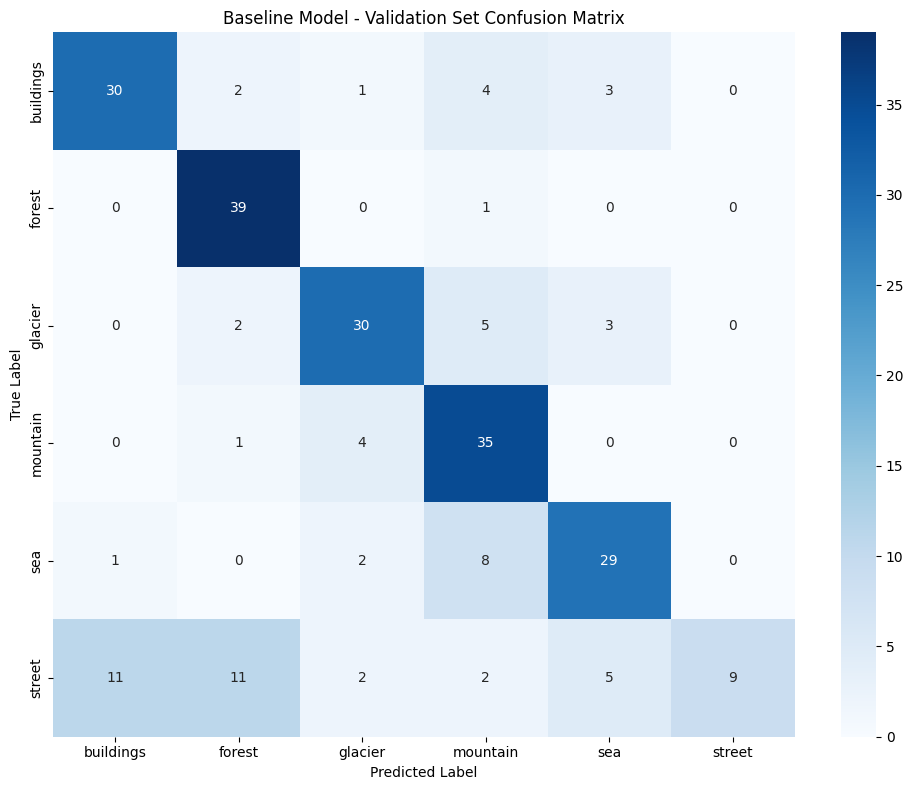

Validation Confusion Matrix saved to evaluation/baseline_validation_confusion_matrix.png


In [110]:
# Generate confusion matrix for validation set
from sklearn.metrics import confusion_matrix

# Create confusion matrix using validation predictions
cm_val = confusion_matrix(all_val_labels, all_val_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Baseline Model - Validation Set Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/baseline_validation_confusion_matrix.png')
plt.show()

print("Validation Confusion Matrix saved to evaluation/baseline_validation_confusion_matrix.png")

In [ ]:
###################

Processed batch [50/388]
Processed batch [100/388]
Processed batch [150/388]
Processed batch [200/388]
Processed batch [250/388]
Processed batch [300/388]
Processed batch [350/388]

Loss Statistics:
Median: 0.3794
75th percentile: 1.1994
90th percentile: 2.2861
95th percentile: 2.8717
99th percentile: 4.3452

Total training samples analyzed: 12402
Mislabeled samples (prediction != true): 3603
High loss samples (>95th percentile): 621


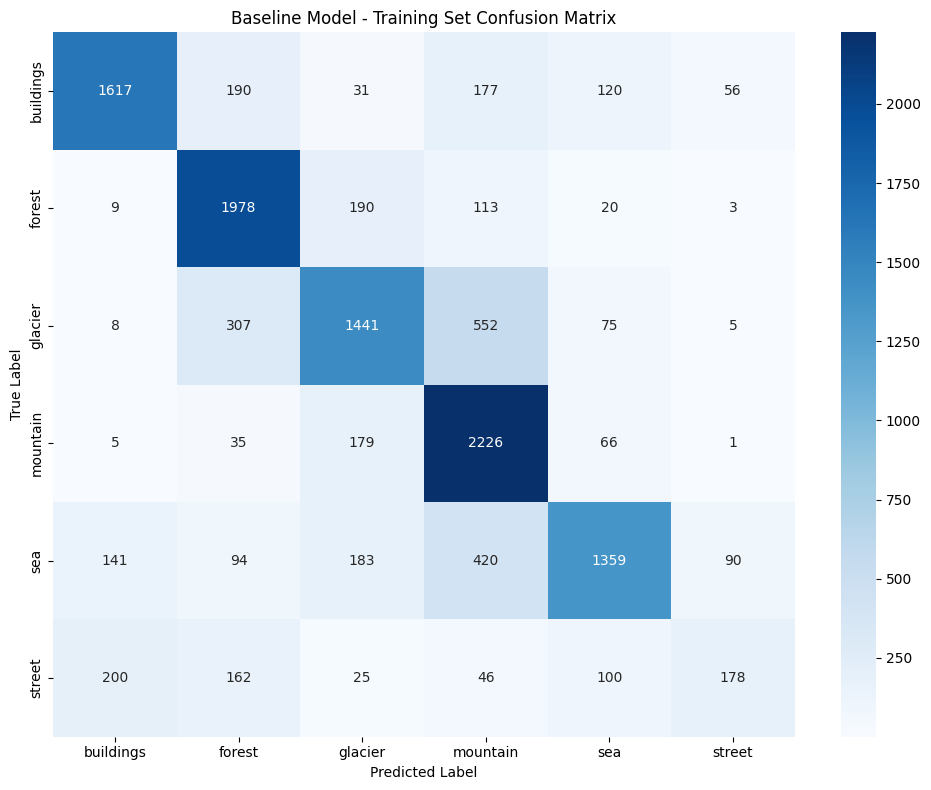

Training Confusion Matrix saved to evaluation/baseline_training_confusion_matrix.png

Training data map created with loss values, logits, and paths for mislabel detection.
Use loss_95th or loss_99th as threshold to identify potentially mislabeled samples.


In [111]:
# Collect raw logits, loss values, and paths for training data analysis
model.eval()
all_train_labels = []
all_train_predictions = []
all_train_logits = []
all_train_paths = []
all_train_losses = []

# Create index to path mapping from dataset
index_to_path = {i: path for i, path in enumerate(train_dataset.images)}

print("Collecting training data with logits, loss values, and paths...")
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass to get raw logits
        logits = model(images)
        
        # Calculate loss for each sample in the batch
        batch_losses = F.cross_entropy(logits, labels, reduction='none')
        
        # Get predictions
        _, predicted = torch.max(logits, 1)
        
        # Store data
        all_train_labels.extend(labels.cpu().numpy())
        all_train_predictions.extend(predicted.cpu().numpy())
        all_train_logits.append(logits.cpu().numpy())
        all_train_losses.extend(batch_losses.cpu().numpy())
        
        # Get paths for this batch
        batch_start_idx = batch_idx * train_loader.batch_size
        batch_end_idx = min(batch_start_idx + len(labels), len(train_dataset))
        batch_paths = [index_to_path[i] for i in range(batch_start_idx, batch_end_idx)]
        all_train_paths.extend(batch_paths)
        
        if (batch_idx + 1) % 50 == 0:
            print(f'Processed batch [{batch_idx+1}/{len(train_loader)}]')

# Concatenate all logits
all_train_logits = np.vstack(all_train_logits)
all_train_losses = np.array(all_train_losses)

# Calculate loss statistics
loss_median = np.median(all_train_losses)
loss_75th = np.percentile(all_train_losses, 75)
loss_90th = np.percentile(all_train_losses, 90)
loss_95th = np.percentile(all_train_losses, 95)
loss_99th = np.percentile(all_train_losses, 99)

print(f"\nLoss Statistics:")
print(f"Median: {loss_median:.4f}")
print(f"75th percentile: {loss_75th:.4f}")
print(f"90th percentile: {loss_90th:.4f}")
print(f"95th percentile: {loss_95th:.4f}")
print(f"99th percentile: {loss_99th:.4f}")

# Create mapping: image_index -> (path, true_label, predicted_label, logits, loss)
training_data_map = {}
for i in range(len(all_train_labels)):
    training_data_map[i] = {
        'path': all_train_paths[i],
        'true_label': all_train_labels[i],
        'predicted_label': all_train_predictions[i],
        'logits': all_train_logits[i],
        'loss': all_train_losses[i],
        'is_mislabeled': all_train_labels[i] != all_train_predictions[i]
    }

print(f"\nTotal training samples analyzed: {len(training_data_map)}")
print(f"Mislabeled samples (prediction != true): {sum(1 for x in training_data_map.values() if x['is_mislabeled'])}")
print(f"High loss samples (>95th percentile): {sum(1 for x in training_data_map.values() if x['loss'] > loss_95th)}")

# Generate confusion matrix for training set
cm_train = confusion_matrix(all_train_labels, all_train_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Baseline Model - Training Set Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/baseline_training_confusion_matrix.png')
plt.show()

print("Training Confusion Matrix saved to evaluation/baseline_training_confusion_matrix.png")
print("\nTraining data map created with loss values, logits, and paths for mislabel detection.")
print("Use loss_95th or loss_99th as threshold to identify potentially mislabeled samples.")

In [112]:
# Remove mislabeled data - samples with cross-entropy loss in 95th percentile
from torch.utils.data import Subset

# Identify indices of samples to keep (loss < 95th percentile)
indices_to_keep = [i for i, data in training_data_map.items() if data['loss'] < loss_90th]
indices_to_remove = [i for i, data in training_data_map.items() if data['loss'] >= loss_90th]

print(f"Original training samples: {len(train_dataset)}")
print(f"Samples to remove (loss >= 90th percentile): {len(indices_to_remove)}")
print(f"Samples to keep (loss < 90th percentile): {len(indices_to_keep)}")
print(f"Removal rate: {100 * len(indices_to_remove) / len(train_dataset):.2f}%")

# Create filtered dataset using Subset
cleaned_train_dataset = Subset(train_dataset, indices_to_keep)

# Create new DataLoader with cleaned dataset
cleaned_train_loader = DataLoader(cleaned_train_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f'Original training dataset size: {len(training_data_map)}')
print(f"\nCleaned training dataset size: {len(cleaned_train_dataset)}")
print(f"Cleaned DataLoader batches: {len(cleaned_train_loader)}")

Original training samples: 12402
Samples to remove (loss >= 90th percentile): 1241
Samples to keep (loss < 90th percentile): 11161
Removal rate: 10.01%
Original training dataset size: 12402

Cleaned training dataset size: 11161
Cleaned DataLoader batches: 349


In [126]:
# Create augmented data loader with class balancing and transformations
num_classes = len(CLASSES)
TARGET_CLASS_INDEX = 5  # 'street'
OVERSAMPLE_MULTIPLIER = 5 #Create 5 transformed versions of each street training sample

# --- 2. DEFINE PIPELINES ---
base_train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(p=0.25), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

heavy_street_transform = transforms.Compose([
    transforms.RandomGrayscale(p=0.25),
    transforms.RandomResizedCrop(size=(150, 150), scale=(0.8, 1.0)),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 3. DEFINE CUSTOM STREAMING DATASET ---
class IntelOutdoorDataset(Dataset):
    def __init__(self, data_dir, transform=None, target_class_idx=None, special_transform=None, multiplier=1):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.target_class_idx = target_class_idx
        self.special_transform = special_transform
        self.multiplier = multiplier
        
        self.images = []
        self.labels = []
        
        for cls_idx, cls in enumerate(CLASSES):
            cls_dir = self.data_dir / cls
            if cls_dir.exists():
                for ext in ["*.jpg", "*.png"]:
                    for img_path in cls_dir.glob(ext):
                        # List expansion for minority class
                        if cls_idx == self.target_class_idx:
                            for _ in range(self.multiplier):
                                self.images.append(str(img_path))
                                self.labels.append(cls_idx)
                        else:
                            self.images.append(str(img_path))
                            self.labels.append(cls_idx)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if label == self.target_class_idx and self.special_transform:
            image = self.special_transform(image)
        elif self.transform:
            image = self.transform(image)
            
        return image, label

# --- 4. STEP A: INITIALIZE FULL AUGMENTED DATASET ---
raw_augmented_dataset = IntelOutdoorDataset(
    data_dir=DATA_DIR,
    transform=base_train_transform,
    target_class_idx=TARGET_CLASS_INDEX,
    special_transform=heavy_street_transform,
    multiplier=OVERSAMPLE_MULTIPLIER
)

# --- 5. STEP B: APPLY YOUR FILTERING LOGIC ---
indices_to_keep = [i for i, data in training_data_map.items() if data['loss'] < loss_95th]
indices_to_remove = [i for i, data in training_data_map.items() if data['loss'] >= loss_95th]

print(f"Original augmented slots: {len(raw_augmented_dataset)}")
print(f"Noisy samples flagged for removal (>= 95th percentile): {len(indices_to_remove)}")
print(f"Verified samples to keep (< 95th percentile): {len(indices_to_keep)}")
print(f"Removal rate: {100 * len(indices_to_remove) / len(raw_augmented_dataset):.2f}%\n")

# Wrap the custom dataset inside PyTorch's Subset tool using your clean indices
cleaned_train_dataset = Subset(raw_augmented_dataset, indices_to_keep)

# --- 6. STEP C: CREATE CLEANED DATALOADER ---
cleaned_train_loader = DataLoader(cleaned_train_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"Cleaned Training Dataset Size: {len(cleaned_train_dataset)}")
print(f"Cleaned DataLoader Batches: {len(cleaned_train_loader)}")

Original augmented slots: 15246
Noisy samples flagged for removal (>= 95th percentile): 621
Verified samples to keep (< 95th percentile): 11781
Removal rate: 4.07%

Cleaned Training Dataset Size: 11781
Cleaned DataLoader Batches: 369


In [128]:
improved_model = CNN(num_classes=len(CLASSES)).to(device)

# 2. Reset the optimizer to track the new model parameters
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(improved_model.parameters(), lr=0.0008)

#Reset weights before running/re-running the training loop for improved model
improved_model.apply(reset_weights)

# 3. Corrected Training Loop
num_epochs = 25 #Train on more epochs since there is greater "variety" in the training set now
improved_model.train()  # Target the new model instance
all_train_labels = []
all_new_train_predictions = []


# Get the accurate total batch count for our cleaned data
total_cleaned_batches = len(cleaned_train_loader)

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Correctly loop through our cleaned, augmented dataloader
    for batch_idx, (images, labels) in enumerate(cleaned_train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = improved_model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # FIXED: Prints relative to the true cleaned batch size
        if (batch_idx + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{total_cleaned_batches}], Loss: {loss.item():.4f}')
    
    # FIXED: Divide accurately by the active cleaned loader length
    epoch_loss = running_loss / total_cleaned_batches
    epoch_acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}] completed. Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%\n')

print('Training for improved model completed!')

Resetting weights **
Resetting weights **
Resetting weights **
Resetting weights **
Resetting weights **
Epoch [1/25], Batch [50/369], Loss: 1.5489
Epoch [1/25], Batch [100/369], Loss: 1.0288
Epoch [1/25], Batch [150/369], Loss: 1.1319
Epoch [1/25], Batch [200/369], Loss: 0.9971
Epoch [1/25], Batch [250/369], Loss: 1.1833
Epoch [1/25], Batch [300/369], Loss: 0.9355
Epoch [1/25], Batch [350/369], Loss: 0.6983
Epoch [1/25] completed. Loss: 1.1883, Accuracy: 56.47%

Epoch [2/25], Batch [50/369], Loss: 1.0812
Epoch [2/25], Batch [100/369], Loss: 0.5621
Epoch [2/25], Batch [150/369], Loss: 0.4841
Epoch [2/25], Batch [200/369], Loss: 0.7220
Epoch [2/25], Batch [250/369], Loss: 0.6382
Epoch [2/25], Batch [300/369], Loss: 1.0385
Epoch [2/25], Batch [350/369], Loss: 0.8843
Epoch [2/25] completed. Loss: 0.8542, Accuracy: 71.15%

Epoch [3/25], Batch [50/369], Loss: 0.8690
Epoch [3/25], Batch [100/369], Loss: 0.6125
Epoch [3/25], Batch [150/369], Loss: 0.9982
Epoch [3/25], Batch [200/369], Loss: 0

In [129]:
#Save the improved mode
# Define the file path
pth_model_path = "improved_model.pth"

# Save the state dictionary
torch.save(improved_model.state_dict(), pth_model_path)
print(f"Model weights successfully saved to {pth_model_path}")

Model weights successfully saved to improved_model.pth


In [ ]:
%pip install onnx onnxscript
import torch.onnx

# 1. Put your model into evaluation mode (crucial for dropout/batchnorm layers)
improved_model.eval()

# 2. Create dummy input matching your training data shape: (batch_size, channels, height, width)
# We match your batch_size of 32 and image dimensions of 150x150
dummy_input = torch.rand(32, 3, 150, 150).to(device)

# 3. Define the file path
onnx_model_path = "improved_model.onnx"

# 4. Export the model
torch.onnx.export(
    improved_model,                  # Your trained model object
    dummy_input,            # Dummy input tensor to trace the architecture
    onnx_model_path,        # Where to save the file
    export_params=True,     # Store the trained parameter weights inside the ONNX file
    opset_version=11,       # Standard, highly compatible ONNX version rule
    do_constant_folding=True, # Optimization trick: folds constant operations
    input_names=['input'],   # Rename input layer for convenience
    output_names=['output'], # Rename output layer for convenience
    # Optional: allows your deployment model to accept flexible batch sizes later
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}} 
)

print(f"Model successfully exported to {onnx_model_path}")

In [130]:
# Collect predictions from improved model on augmented training set
improved_model.eval()
all_augmented_train_labels = []
all_augmented_train_predictions = []

print("Collecting predictions from improved model on augmented training set...")
with torch.no_grad():
    for images, labels in cleaned_train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = improved_model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_augmented_train_labels.extend(labels.cpu().numpy())
        all_augmented_train_predictions.extend(predicted.cpu().numpy())

print(f"Total samples evaluated: {len(all_augmented_train_labels)}")

Total samples evaluated: 11781


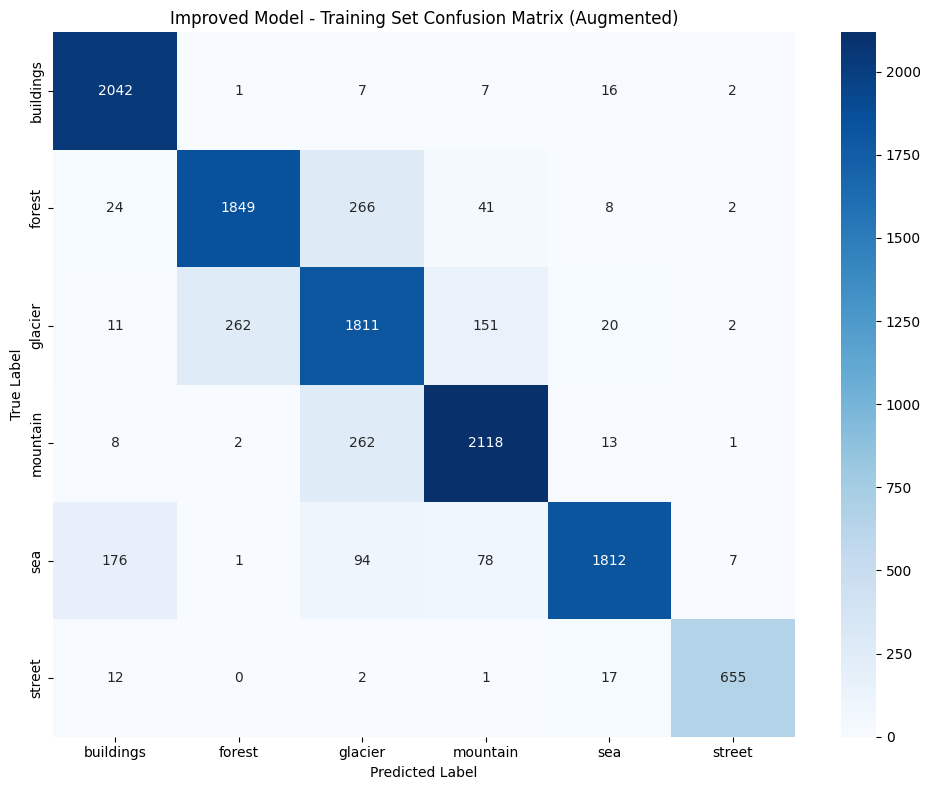

Improved Model Training Confusion Matrix saved to evaluation/improved_training_confusion_matrix.png


In [131]:
#Confusion matrix on the augmented training data for the improved model
# Generate confusion matrix for training set
new_cm_train = confusion_matrix(all_augmented_train_labels, all_augmented_train_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(new_cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Improved Model - Training Set Confusion Matrix (Augmented)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/improved_training_confusion_matrix.png')
plt.show()

print("Improved Model Training Confusion Matrix saved to evaluation/improved_training_confusion_matrix.png")

In [132]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DEFINE VALIDATION SPECIFIC TRANSFORM ---
# Crucial: Validation data must remain static. No random cropping or jitter!
base_val_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    # Directly convert to tensor and normalize without random alterations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. INITIALIZE VALIDATION DATASET & LOADER ---
val_data_dir = "dataset/validation_data"

# We use the IntelOutdoorDataset class without target_class multipliers or special transforms
val_dataset = IntelOutdoorDataset(
    data_dir=val_data_dir, 
    transform=base_val_transform,
    target_class_idx=None,
    special_transform=None,
    multiplier=1
)

# shuffle=False is critical for evaluation so metrics align correctly
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Validation samples indexed: {len(val_dataset)}")

# --- 3. EVALUATE THE IMPROVED MODEL ---
improved_model.eval() # Freezes Dropout and BatchNorm layers 

val_correct = 0
val_total = 0
all_val_labels = []
all_val_predictions = []

# Disable gradient tracking to save immense memory and speed up computation
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass through the updated  model
        outputs = improved_model(images)
        _, predicted = torch.max(outputs, 1)
        
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        
        # Pull data back to CPU for Scikit-Learn compliance
        all_val_labels.extend(labels.cpu().numpy())
        all_val_predictions.extend(predicted.cpu().numpy())

# --- 4. DISPLAY METRICS ---
val_accuracy = 100 * val_correct / val_total
print(f'\nImproved Model Validation Accuracy: {val_accuracy:.2f}%')

# Calculates the true gap using your last computed training accuracy variable (epoch_acc)
if 'epoch_acc' in locals():
    print(f'Generalization Accuracy Gap (Train vs Val): {epoch_acc - val_accuracy:.2f}%')
else:
    print("Generalization Accuracy Gap: Run training cell first to compare against training accuracy.")

# Print detailed classification report to see precision/recall metrics per class
print("\nValidation Classification Report:")
print(classification_report(all_val_labels, all_val_predictions, target_names=CLASSES))



Validation samples indexed: 240

Improved Model Validation Accuracy: 75.42%
Generalization Accuracy Gap (Train vs Val): 11.22%

Validation Classification Report:
              precision    recall  f1-score   support

   buildings       0.60      0.97      0.74        40
      forest       0.97      0.97      0.97        40
     glacier       0.73      0.82      0.78        40
    mountain       0.82      0.90      0.86        40
         sea       0.73      0.82      0.78        40
      street       1.00      0.03      0.05        40

    accuracy                           0.75       240
   macro avg       0.81      0.75      0.70       240
weighted avg       0.81      0.75      0.70       240



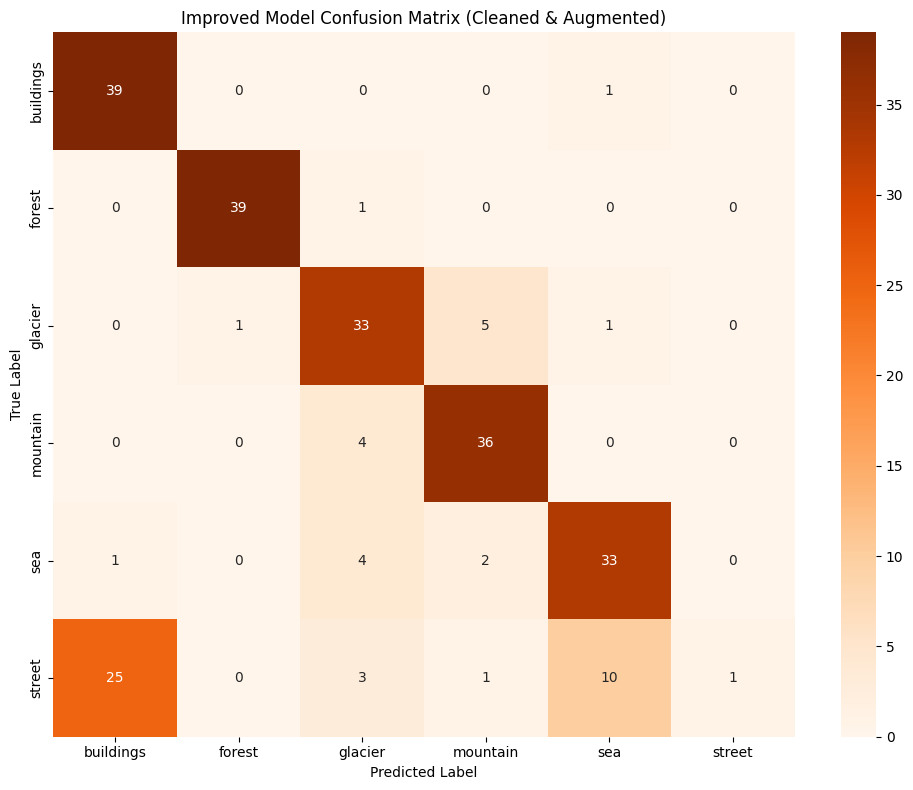

In [133]:
# --- 5. BONUS: VISUALIZE NEW CONFUSION MATRIX ---
# This saves a new plot so you can visually verify if the 'street' class accuracy improved
cm = confusion_matrix(all_val_labels, all_val_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Improved Model Confusion Matrix (Cleaned & Augmented)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save separate from the baseline plot to compare them side-by-side
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/improved_confusion_matrix.png')
plt.show()

In [ ]:
# Generate confusion matrix
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Baseline Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/baseline_confusion_matrix.png')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=CLASSES))